# Code to generate Figure 3 subplots

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from tqdm import trange
import matplotlib.ticker as ticker

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

Remove proteins with low pLDDT and/or proteins predicted to be membrane proteins

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['TM', 'SP+TM', 'Beta']))
].copy()

# print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2529


### Figure 3a-d
1. Create histograms to visualise distribution of three stability-related metrics across AE-MS dataset; Ghosh-Dill ΔG, Cagiada ΔG, Rosetta Total Score

We first preprocess the data for visualization purposes

In [4]:
# 1. Ghosh-Dill-dG
vals1 = filtered_nodes["Ghosh-Dill-dG"].dropna()

# 2. cagiada-dG (multiply by -1 for plotting)
vals2 = -1 * filtered_nodes["cagiada-dG"].dropna()

# 3. Rosetta Total Score (with extreme-outlier filtering)
vals3 = filtered_nodes["Rosetta_best_total_score"].dropna()

# Calculate IQR for outlier detection for Rosetta data

Q1 = np.percentile(vals3, 25)
Q3 = np.percentile(vals3, 75)
IQR = Q3 - Q1

# Standard outliers (for reference)
# Outlier thresholds
upper_threshold = Q3 + 1.5 * IQR        # standard outliers
extreme_upper = Q3 + 3 * IQR            # extreme outliers (highly skewed)

# Count outliers
num_standard = (vals3 > upper_threshold).sum()
num_extreme = (vals3 > extreme_upper).sum()

print(f"Standard outliers (> Q3 + 1.5*IQR): {num_standard}")
print(f"Highly skewed proteins (> Q3 + 3*IQR): {num_extreme}")

# Identify extreme proteins (index-safe)
extreme_condition = vals3 > extreme_upper
extreme_proteins = filtered_nodes.loc[vals3.index[extreme_condition]]

print("\nHighly skewed proteins (extreme outliers > Q3 + 3*IQR):")
if not extreme_proteins.empty:
    print(extreme_proteins[["Rosetta_best_total_score"]]
          .sort_values(by="Rosetta_best_total_score", ascending=False))
    print(f"Protein identifiers: {extreme_proteins.index.tolist()}")
else:
    print("None found.")

# Filter for plotting only
vals3_filtered = vals3.loc[vals3 <= extreme_upper]

# 4. Meltome-melting-point BUT only where meltome-fit-R2 > 0.9
melt_filter = filtered_nodes["meltome-fit-R2"] > 0.9
vals4 = filtered_nodes.loc[melt_filter, "meltome-melting-point"].dropna()

vals_list = [vals1, vals2, vals3_filtered, vals4]

Standard outliers (> Q3 + 1.5*IQR): 6
Highly skewed proteins (> Q3 + 3*IQR): 5

Highly skewed proteins (extreme outliers > Q3 + 3*IQR):
      Rosetta_best_total_score
2117                 83446.889
873                  30812.001
1902                 20906.254
3814                  9460.659
57                    2609.099
Protein identifiers: [57, 873, 1902, 2117, 3814]


And then create the plot

-12.067769848492222
-18.86229860989412
-1305.276377328577
48.78051398337112


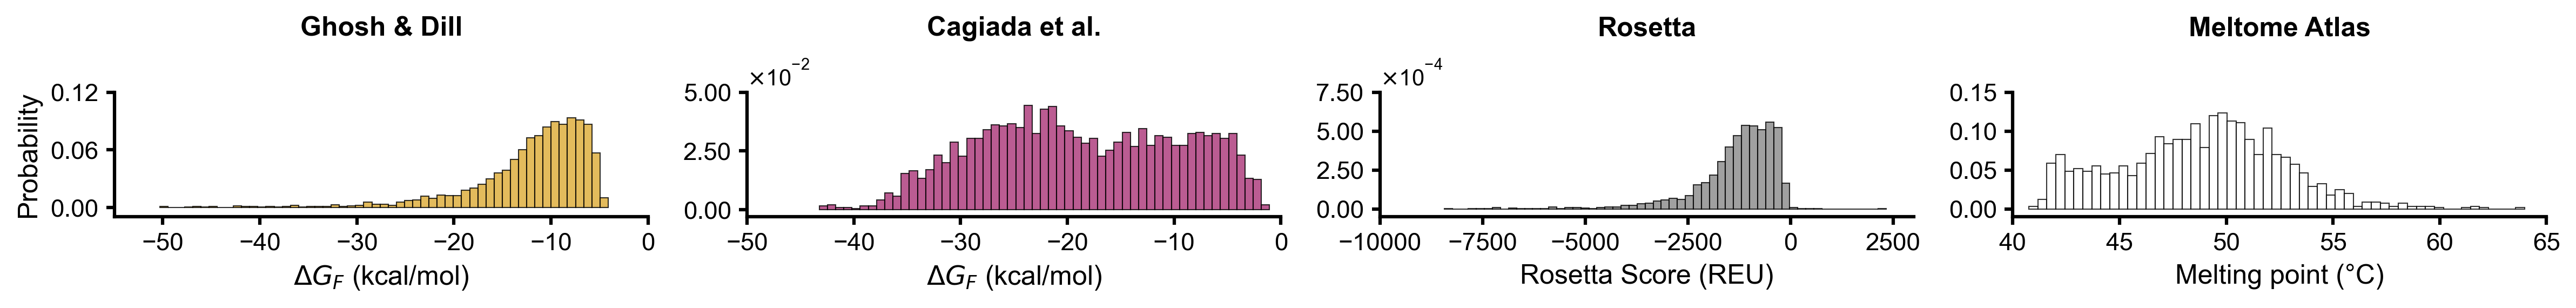

In [5]:
from matplotlib.ticker import ScalarFormatter

# Custom formatter
class TwoDecimalScalarFormatter(ScalarFormatter):
    def _set_format(self):
        self.format = "%.2f"
        
bins = 55

xlabels = [
    r"$\Delta G_F$ (kcal/mol)",
    r"$\Delta G_F$ (kcal/mol)",
    "Rosetta Score (REU)",
    r"Melting point (°C)",
]

titles = [
    "Ghosh & Dill",
    "Cagiada et al.",
    "Rosetta",
    "Meltome Atlas",
]

colors = [
    "#DDAA33",   # Ghosh-Dill
    "#AA3377",   # Cagiada
    "#888888",   # Rosetta
    "white",     # Meltome
]

xlims = [
    (-55, 0),              
    (-50, 0),              
    (-10000, 3000),              
    (40, 65),              
]

ylims = [
    (-0.01, 0.125),              
    (-0.003, 0.05),
    (-0.00005, 0.00075),
    (-0.01, 0.15),
]

xticks_list = [
    None,              
    None,
    [-10000, -7500, -5000, -2500, 0, 2500],
    None,
]

yticks_list = [
    [0, 0.0625, 0.125],              
    [0, 0.025, 0.05],
    [0.0, 0.00025, 0.00050, 0.00075],
    [0.0, 0.05, 0.1, 0.15],
]

fig, axes = plt.subplots(1, 4, figsize=(16, 2))

for i, (ax, vals, xlabel, title, color) in enumerate(zip(axes, vals_list, xlabels, titles, colors)):
    print(np.mean(vals))

    # common axis styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.tick_params(axis="both", direction="out", width=1.5)
    ax.grid(False)

    # histogram with thin black outline
    ax.hist(
        vals,
        bins=bins,
        density=True,
        color=color,
        alpha=0.8,
        edgecolor="black",   # outline color
        linewidth=0.5,       # thin but visible
    )

    # manual axis limits if provided
    if xlims[i] is not None:
        ax.set_xlim(xlims[i])
    if ylims[i] is not None:
        ax.set_ylim(ylims[i])

    # manual ticks if provided
    if xticks_list[i] is not None:
        ax.set_xticks(xticks_list[i])
    if yticks_list[i] is not None:
        ax.set_yticks(yticks_list[i])

    # NEW: y-axis formatting
    formatter = TwoDecimalScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    formatter.set_useOffset(False)

    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(-2, 2))

    # labels
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis="both", labelsize=11)

# only put y-label on the first subplot (keep your current behavior)
axes[0].set_ylabel("Probability", fontsize=12)

fig.tight_layout()
fig.savefig("3a-d.svg")
plt.show()

### Figure 3e-h
1. Create boxplots of stability metrices and melting point for hubs and non-Hubs in mass spec dataset

In [6]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01477; there are 261 hubs and 2268 non hubs


In [7]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_values(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

# Only remove inf/nan — DO NOT require > 0
ms_hub_vals    = ms_hubs["Ghosh-Dill-dG"].replace([np.inf, -np.inf], np.nan).dropna()
ms_nothub_vals = ms_nothub["Ghosh-Dill-dG"].replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████| 1000000/1000000 [00:14<00:00, 67751.37it/s]


MS hubs: median=-8.14, 95% CI=(-8.65, -7.93), n=261)


Bootstrapping medians: 100%|████████████████████████████| 1000000/1000000 [00:39<00:00, 25540.47it/s]


MS non-hubs: median=-10.81, 95% CI=(-11.11, -10.57), n=2267)


In [8]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
#y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="greater")

# Y2H: hubs vs non-hubs
#y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== (greater) Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

MS hubs vs MS non-hubs
n(hubs) = 261, n(non-hubs) = 2267
median(hubs) = -8.14, median(non-hubs) = -10.81
U = 379688.00, p = 5.989e-14
=== (greater) Mann–Whitney U tests on Ghosh-Dill-dG ===

MS hubs vs MS non-hubs
n(hubs) = 261, n(non-hubs) = 2267
median(hubs) = -8.14, median(non-hubs) = -10.81
U = 379688.00, p = 2.995e-14


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_84391/54361772.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


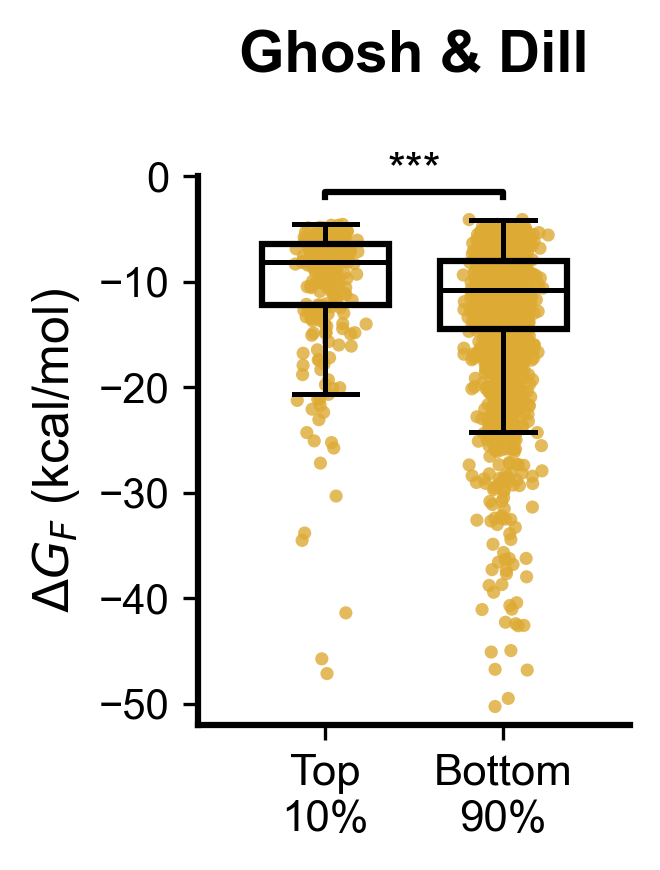

In [9]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.5
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)

ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Ghosh & Dill", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(ms_hub_vals.min(), ms_nothub_vals.min())
y_max = max(ms_hub_vals.max(), ms_nothub_vals.max())

# Significance bracket slightly above the highest data point
bracket_y = -2

# IMPORTANT: set ylim AFTER computing bracket_y
ax.set_ylim(-52, 0)

# Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

plt.xticks(fontsize=10.5)
plt.tight_layout()
plt.savefig("3f.svg")
plt.show()

In [10]:
# multiply cagiada-dG by -1) ===
ms_hubs["cagiada-dG"]    = -ms_hubs["cagiada-dG"]
ms_nothub["cagiada-dG"]  = -ms_nothub["cagiada-dG"]
# Only remove inf/nan — DO NOT require > 0
ms_hub_vals    = ms_hubs["cagiada-dG"].replace([np.inf, -np.inf], np.nan).dropna()
ms_nothub_vals = ms_nothub["cagiada-dG"].replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_84391/4012345631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_hubs["cagiada-dG"]    = -ms_hubs["cagiada-dG"]
/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_84391/4012345631.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_nothub["cagiada-dG"]  = -ms_nothub["cagiada-dG"]
Bootstrapping medians: 100%|████████████████████████████| 1000000/1000000 [00:14<00:00, 67782.48it/s]


MS hubs: median=-11.50, 95% CI=(-13.06, -10.34), n=261)


Bootstrapping medians: 100%|████████████████████████████| 1000000/1000000 [00:39<00:00, 25412.61it/s]


MS non-hubs: median=-20.22, 95% CI=(-20.75, -19.63), n=2267)


In [11]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("=== (greater) Mann–Whitney U tests on cagiada-dG ===")

ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="greater")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

MS hubs vs MS non-hubs
n(hubs) = 261, n(non-hubs) = 2267
median(hubs) = -11.50, median(non-hubs) = -20.22
U = 388879.00, p = 7.991e-17
=== (greater) Mann–Whitney U tests on cagiada-dG ===

MS hubs vs MS non-hubs
n(hubs) = 261, n(non-hubs) = 2267
median(hubs) = -11.50, median(non-hubs) = -20.22
U = 388879.00, p = 3.996e-17


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_84391/2199875941.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


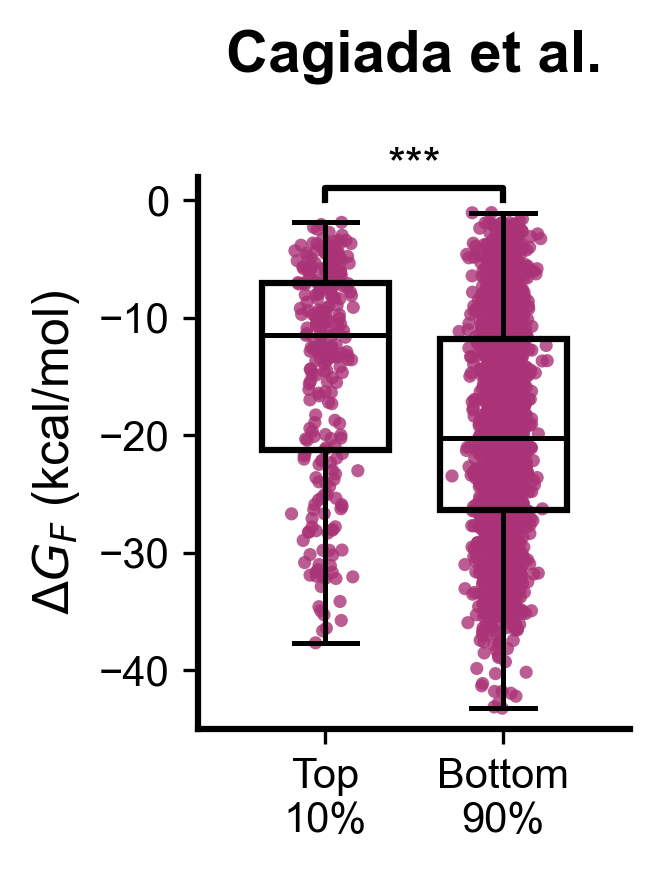

In [12]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = ['#AA3377',    '#AA3377']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Cagiada et al.", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(ms_hub_vals.min(), ms_nothub_vals.min())
y_max = 10
ax.set_ylim(-45, 2)   # 5% padding at bottom, 0 at top

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 0  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig(f"3g.svg")
plt.show()

In [13]:
# Only remove inf/nan — DO NOT require > 0
ms_hub_vals = (
    ms_hubs["Rosetta_best_total_score"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .loc[lambda x: x <= extreme_upper]
)

ms_nothub_vals = (
    ms_nothub["Rosetta_best_total_score"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .loc[lambda x: x <= extreme_upper]
)

# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████| 1000000/1000000 [00:14<00:00, 67969.07it/s]


MS hubs: median=-677.12, 95% CI=(-754.65, -603.00), n=261)


Bootstrapping medians: 100%|████████████████████████████| 1000000/1000000 [00:39<00:00, 25451.58it/s]

MS non-hubs: median=-1124.43, 95% CI=(-1158.22, -1098.95), n=2262)


In [14]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
#y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="greater")

# Y2H: hubs vs non-hubs
#y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== (greater) Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

MS hubs vs MS non-hubs
n(hubs) = 261, n(non-hubs) = 2262
median(hubs) = -677.12, median(non-hubs) = -1124.43
U = 384120.00, p = 1.46e-15
=== (greater) Mann–Whitney U tests on Rosetta_best_total_score ===

MS hubs vs MS non-hubs
n(hubs) = 261, n(non-hubs) = 2262
median(hubs) = -677.12, median(non-hubs) = -1124.43
U = 384120.00, p = 7.298e-16


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_84391/788066070.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


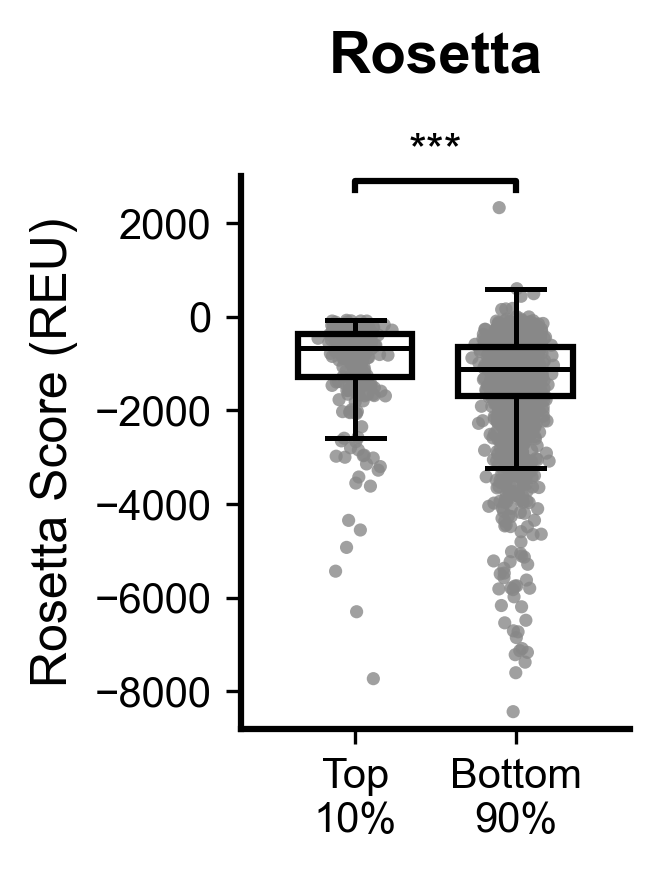

In [15]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 200
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
        clip_on=False,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = ['#888888',    '#888888']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]

for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---

ax.set_ylabel("Rosetta Score (REU)", fontsize=12)
ax.set_title("Rosetta", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(ms_hub_vals.min(), ms_nothub_vals.min())
y_max = max(ms_hub_vals.max(), ms_nothub_vals.max())
#ax.set_ylim(y_min * 1.2, y_max * 1.2)
ax.set_ylim(-8800, 3000)

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 2700  # you can adjust: -1, -3, -5 depending on taste
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("3e.svg")
plt.show()

In [16]:
# Filter for proteins with 'meltome-fit-R2' > 0.9 and Only remove inf/nan — DO NOT require > 0
ms_hub_vals = ms_hubs[ms_hubs['meltome-fit-R2'] > 0.9]["meltome-melting-point"]\
    .replace([np.inf, -np.inf], np.nan).dropna()

ms_nothub_vals = ms_nothub[ms_nothub['meltome-fit-R2'] > 0.9]["meltome-melting-point"]\
    .replace([np.inf, -np.inf], np.nan).dropna()
# Groups: (label, data, color)
groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
]

# -------------------------------------------------------
# 4. Compute bootstrapped medians + CIs
# -------------------------------------------------------
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|████████████████████████████| 1000000/1000000 [00:14<00:00, 71217.52it/s]


MS hubs: median=44.68, 95% CI=(44.09, 46.22), n=186)


Bootstrapping medians: 100%|████████████████████████████| 1000000/1000000 [00:25<00:00, 38928.24it/s]

MS non-hubs: median=49.47, 95% CI=(49.23, 49.70), n=1137)


In [17]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="less")

print("=== (less) Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS hubs vs MS non-hubs")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

MS hubs vs MS non-hubs
n(hubs) = 186, n(non-hubs) = 1137
median(hubs) = 44.68, median(non-hubs) = 49.47
U = 52873.50, p = 7.062e-28
=== (less) Mann–Whitney U tests on meltome-melting-point ===

MS hubs vs MS non-hubs
n(hubs) = 186, n(non-hubs) = 1137
median(hubs) = 44.68, median(non-hubs) = 49.47
U = 52873.50, p = 3.531e-28


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_84391/241832812.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


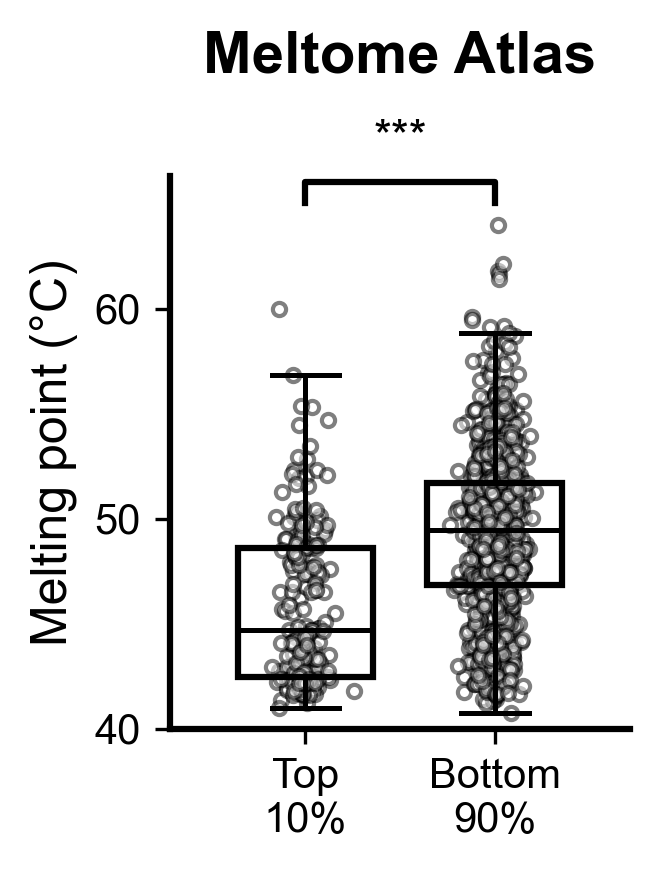

In [18]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(2.3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals]
group_colors = ['white',    'white']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]

for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        facecolor="white",   # inside color
        edgecolor="black",
        alpha=0.5,
        color=color,
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Top\n10%", "Bottom\n90%"],
    positions=[1, 1.7],   
    widths=0.5,             
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
#ax.set_yscale("log")
#ax.set_ylim(1, 1e7)

ax.set_ylabel("Melting point (°C)", fontsize=12)
ax.set_title("Meltome Atlas", fontweight='bold')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = 40     # a little below the real minimum
y_max = 66.3     # enough headroom for the bracket
ax.set_ylim(y_min, y_max)
ax.set_yticks([40, 50, 60])          # ← forces exactly these ticks
ax.set_yticklabels([40, 50, 60])

# Place significance bracket at a fixed, nice height just above 0
bracket_y = 65
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "***")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("3h.svg")
plt.show()